# Logistic Regression

Logistic regression is a supervised classification algorithm designed to predict the probability of an occurrence of an event.

In this project, we will build a single artificial neuron to predict whether a patient is a smoker based on their medical charges and BMI. This is a binary classification problem where:
- 0: Non-smoker
- 1: Smoker


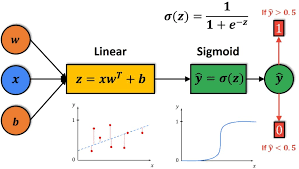




First, let's visualise the relationship between medical chanrges and the presense of absence of smoking status. Each point represents a different patient. (Smokers are green, Non-smokers are magenta)

Manually assigned y-values of 0 and 1 make the plot easy to interpret and drawing a vertical line at $30,000 as a possible threshold for separating the two classes.



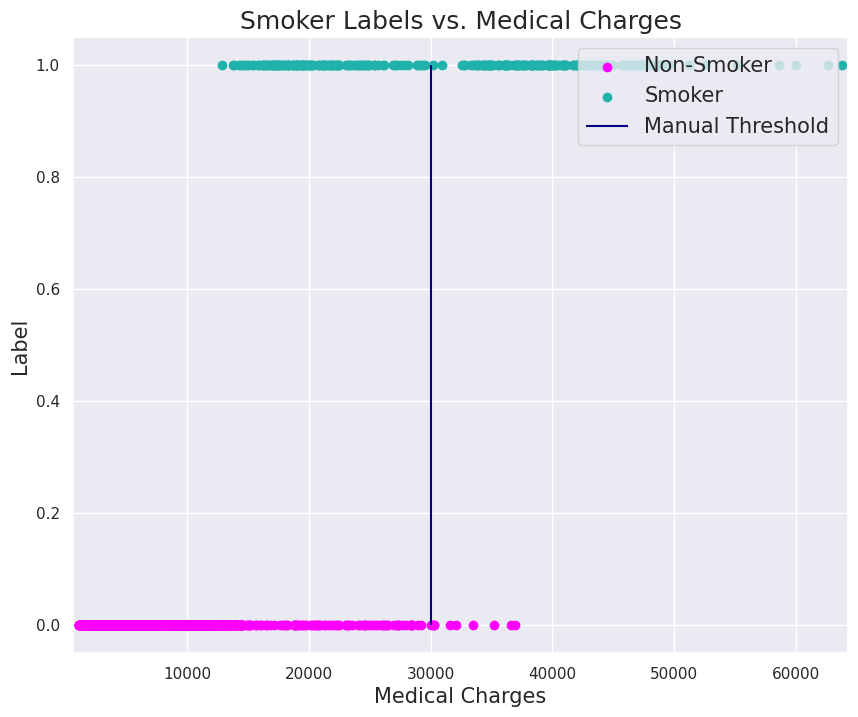

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set the Seaborn theme
sns.set_theme()

# Read the insurance dataset
df = pd.read_csv("insurance.csv")

# Create subsets depending on 'target' outcome
# 0 = Non-smoker, 1 = Smoker
no_smoker = df[df['smoker'] == 'no']
smoker = df[df['smoker'] == 'yes']

plt.figure(figsize=(10, 8))
plt.xlim((df['charges'].min() - 500, df['charges'].max() + 500))

# Plot 0s and 1s manually for illustration
plt.scatter(no_smoker['charges'], np.zeros(len(no_smoker)), color="magenta", label="Non-Smoker")
plt.scatter(smoker['charges'], np.ones(len(smoker)), color="lightseagreen", label="Smoker")
plt.vlines(x=30000, ymin=0, ymax=1, color='navy', label="Manual Threshold")

plt.xlabel("Medical Charges", fontsize=15)
plt.ylabel("Label", fontsize=15)
plt.legend(fontsize=15, loc="upper right")
plt.title("Smoker Labels vs. Medical Charges", fontsize=18)
plt.show()

Also keep in mind that there is no perfect cutoff, which is why we will fit a logistic regression model to learn the best probabilistic decision boundary based on the data and its distribution.

### Sigmoid Function


$$\sigma(z) = \frac{1}{1 + e^{-z}}$$


Logistic regression uses the sigmoid function to map inputs into probabilities. The plot below will show:

The relationship between charges and target class.

The sigmoid function σ(z) which smoothly transitions between 0 and 1.

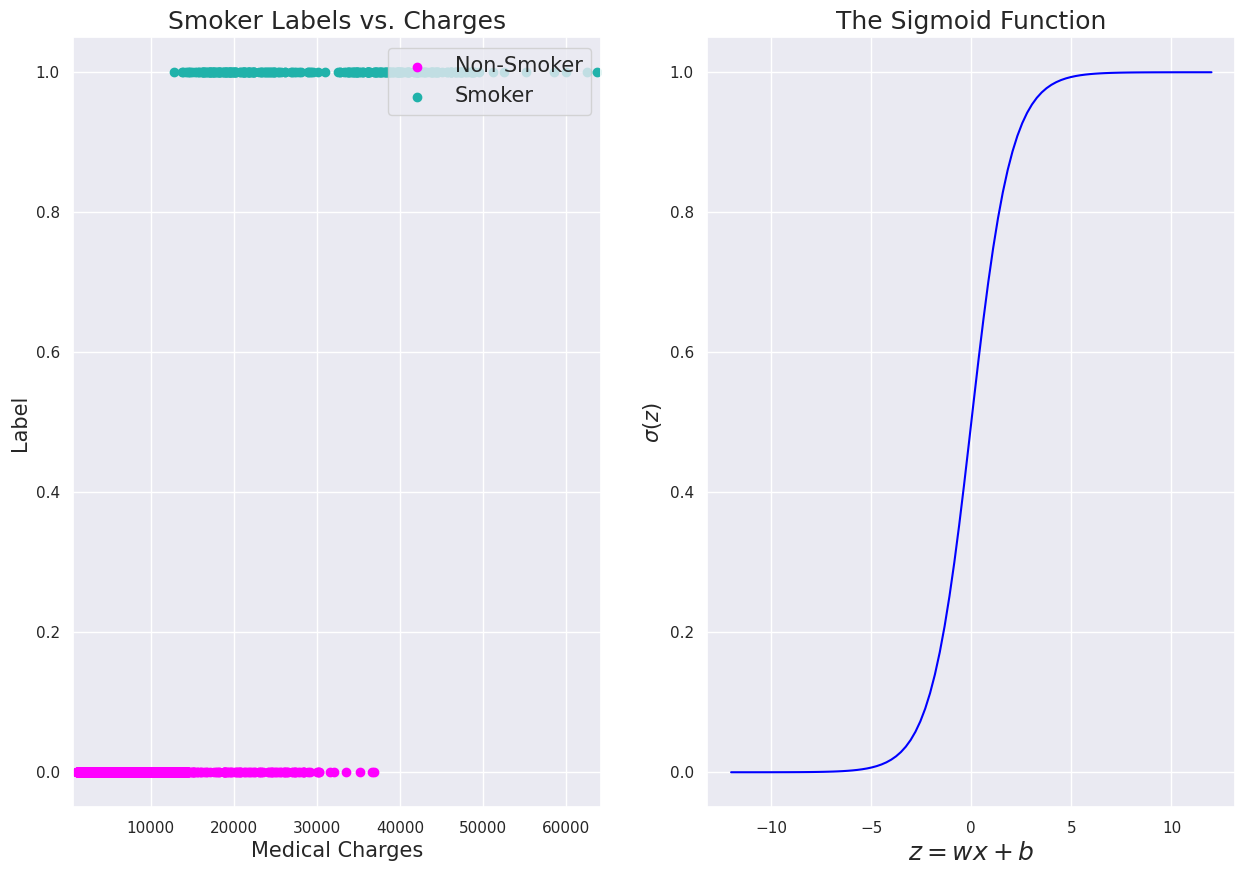

In [22]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

# Left plot: 1D scatter of charges vs. labels
ax1.set_xlim((df['charges'].min() - 500, df['charges'].max() + 500))
ax1.scatter(no_smoker['charges'], np.zeros(len(no_smoker)), color="magenta", label="Non-Smoker")
ax1.scatter(smoker['charges'], np.ones(len(smoker)), color="lightseagreen", label="Smoker")
ax1.set_xlabel("Medical Charges", fontsize=15)
ax1.set_ylabel("Label", fontsize=15)
ax1.set_title("Smoker Labels vs. Charges", fontsize=18)
ax1.legend(fontsize=15, loc="upper right")

# Right plot: Sigmoid function
domain = np.linspace(-12.0, 12.0, 100)
ax2.plot(domain, sigmoid(domain), color="blue", label=r"$\sigma(z)$")
ax2.set_xlabel(r"$z = wx + b$", fontsize=18)
ax2.set_ylabel(r"$\sigma(z)$", fontsize=15)
ax2.set_title("The Sigmoid Function", fontsize=18)
plt.show()

### Single Neuron Model

This neuron uses stochastic gradient descent to optimize weights and bias based on sigmoid activation and a selected cost function (cross-entropy).

In [23]:
class SingleNeuron(object):
    """
    A class used to represent a single artificial neuron.
    """
    def __init__(self, activation_function, cost_function):
        self.activation_function = activation_function
        self.cost_function = cost_function

    def train(self, X, y, alpha = 0.005, epochs = 50):
        # Initializing weights (last entry is bias)
        self.w_ = np.random.rand(1 + X.shape[1])
        self.errors_ = []
        N = X.shape[0]

        for _ in range(epochs):
            errors = 0
            for xi, target in zip(X, y):
                y_hat = self.predict(xi)
                error = (y_hat - target)
                self.w_[:-1] -= alpha * error * xi  # Updates weights for features
                self.w_[-1] -= alpha * float(error) # Ensures error is a single scalar number
                errors += self.cost_function(self.predict(xi), target)
            self.errors_.append(errors/N)
        return self

    def predict(self, X):
        X = np.atleast_2d(X)
        preactivation = np.dot(X, self.w_[:-1]) + self.w_[-1]
        return self.activation_function(preactivation)

    def plot_cost_function(self):
        fig, axs = plt.subplots(figsize = (10, 8))
        axs.plot(range(1, len(self.errors_) + 1), self.errors_, label = "Cost function")
        axs.set_xlabel("epochs", fontsize = 15)
        axs.set_ylabel("Cost", fontsize = 15)
        axs.legend(fontsize = 15)
        axs.set_title("Cost Calculated after Epoch During Training", fontsize = 18)
        plt.show()

    def plot_decision_boundary(self, X, y, xstring="x", ystring="y"):
        plt.figure(figsize = (10, 8))
        # Custom boundary plot logic
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
        Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, alpha=0.4, cmap='magma')
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='magma')
        plt.title("Neuron Decision Boundary", fontsize = 18)
        plt.xlabel(xstring, fontsize = 15)
        plt.ylabel(ystring, fontsize = 15)
        plt.show()

### Binary cross Entropy Loss and Training

Now we can define the cross-entropy loss function and pass our features into the SingleNeuron.train() method.

/tmp/ipykernel_5461/438307296.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.w_[-1] -= alpha * float(error) # Ensures error is a single scalar number


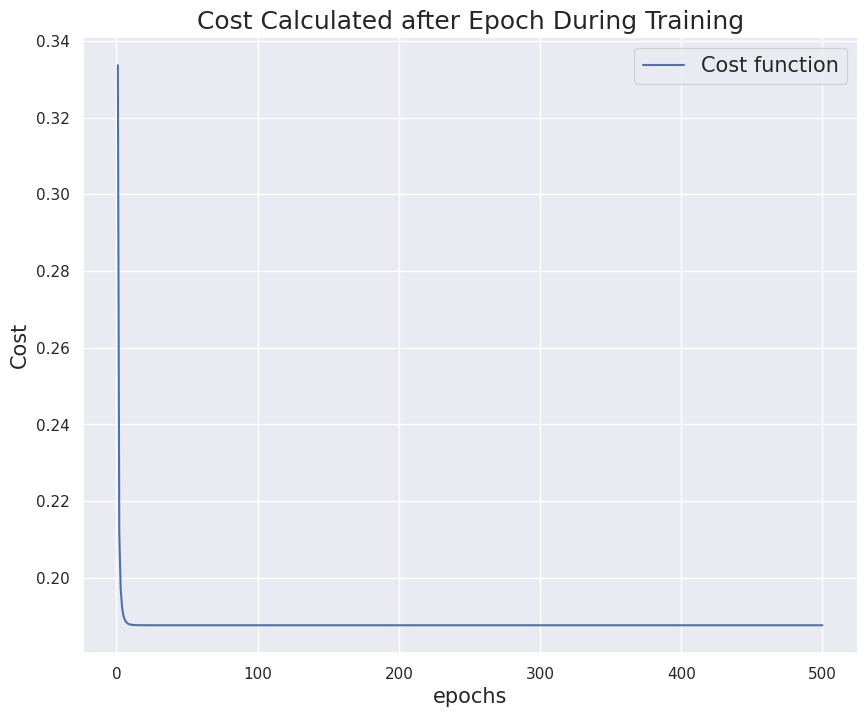

 Classification Error = 0.09940209267563528


In [24]:
def cross_entropy_loss(y_hat, y):
    y_hat = np.clip(y_hat, 1e-10, 1 - (1e-10))
    return - y*np.log(y_hat) - (1 - y)*np.log(1 - y_hat)

# Initialize neuron
node = SingleNeuron(sigmoid, cross_entropy_loss)

# Preprocessing our specific variables
from sklearn.preprocessing import StandardScaler

# Scale the charges
scaler = StandardScaler()
X_raw = df['charges'].values.reshape(-1, 1)
X = scaler.fit_transform(X_raw)

y = df['smoker'].apply(lambda x: 1 if x.lower() == 'yes' else 0).values

# Train using the scaled X and a slightly higher learning rate
node = SingleNeuron(sigmoid, cross_entropy_loss)
node.train(X, y, alpha=0.01, epochs=500)
node.plot_cost_function()

# re-calculate your error
classification_error = (np.rint(node.predict(X)) != y).astype(int)
print(f" Classification Error = {sum(classification_error) / len(y)}")

The Learned Logistic Curve:

After I train the 1D model (Charges only),we would need a plot showing the "learned sigmoid" overlaying the actual data. Without this, we only have a cost graph, but haven't shown how the model actually looks in 1D.

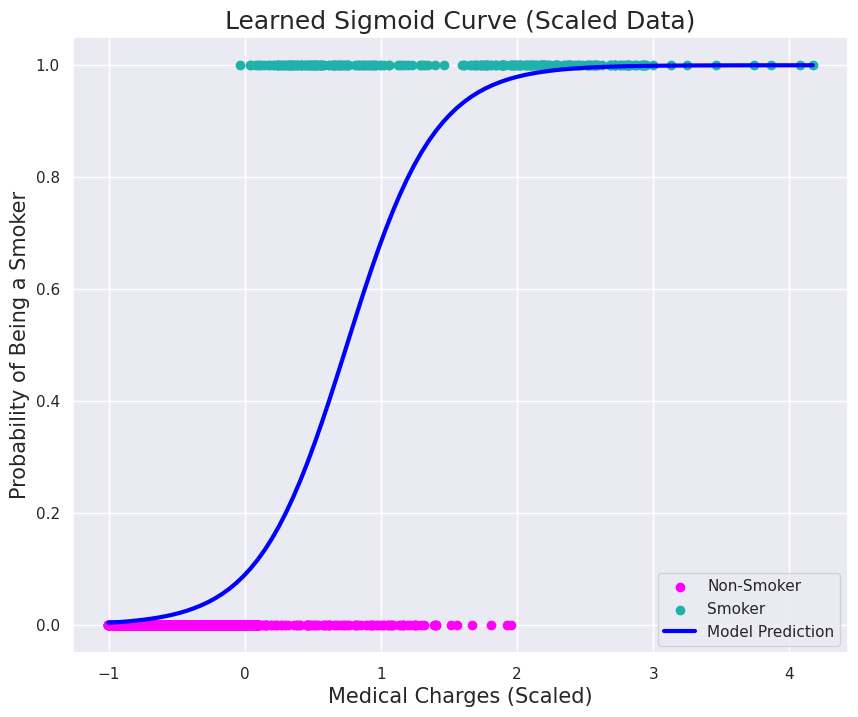

In [25]:
plt.figure(figsize=(10, 8))

# Use the scaled X and y
plt.scatter(X[y == 0], np.zeros(len(X[y == 0])), color="magenta", label="Non-Smoker")
plt.scatter(X[y == 1], np.ones(len(X[y == 1])), color="lightseagreen", label="Smoker")

# Create a smooth line for the prediction curve
domain = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(domain, node.predict(domain), color="blue", lw=3, label="Model Prediction")

plt.xlabel("Medical Charges (Scaled)", fontsize=15)
plt.ylabel("Probability of Being a Smoker", fontsize=15)
plt.legend()
plt.title("Learned Sigmoid Curve (Scaled Data)", fontsize=18)
plt.show()

### Findings

After training the model on the charges feature, we can observe the learned sigmoid curve and decision boundary. We may observe that a single feature like charges is insufficient for perfect classification, requiring us to experiment with additional scaled features like BMI.

We compute the classification error by rounding predicted probabilities to the nearest class (0 or 1) and comparing them with true labels.

Also, when I introduce the second model (Charges + BMI),we shouldn't just show the boundary. We can plot both cost curves on one graph to prove the 2D model was actually better (or different).

/tmp/ipykernel_5461/438307296.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.w_[-1] -= alpha * float(error) # Ensures error is a single scalar number


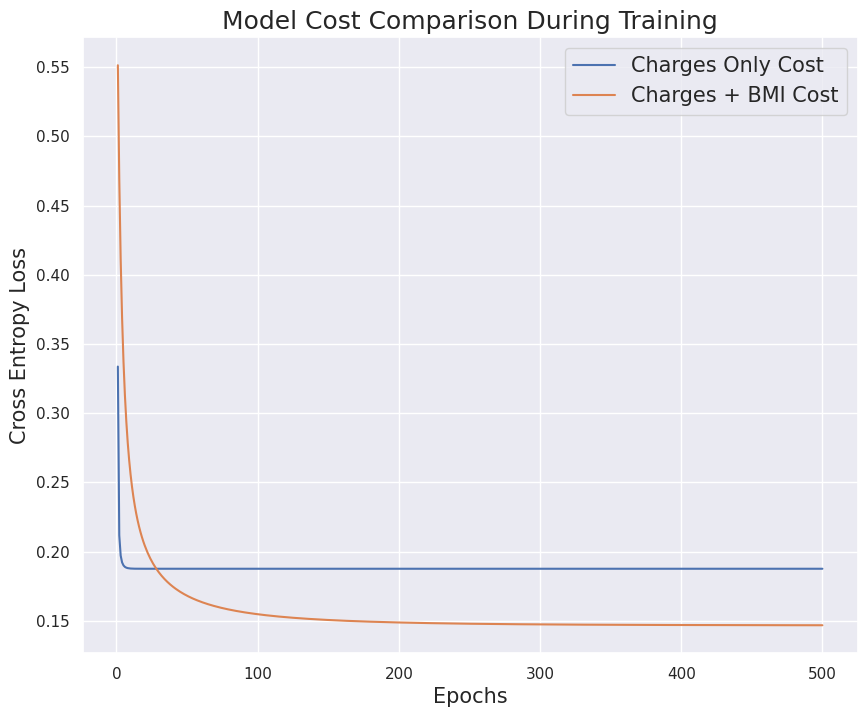

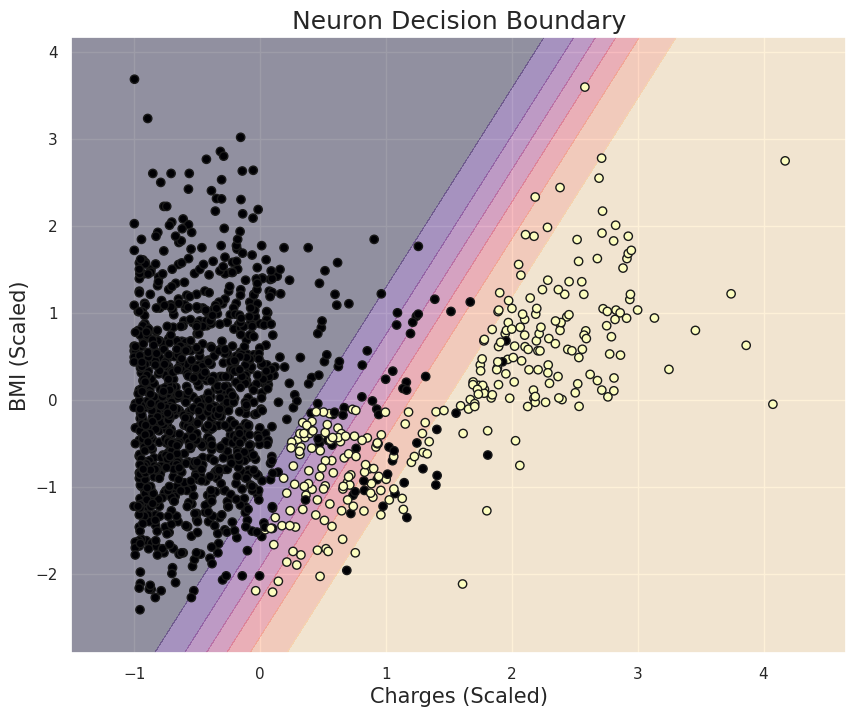

In [26]:
# Experimenting with Charges and BMI
X_better = df[['charges', 'bmi']].values
scaler = StandardScaler()
X_better_scaled = scaler.fit_transform(X_better)

node_better = SingleNeuron(sigmoid, cross_entropy_loss)
node_better.train(X_better_scaled, y, alpha=0.0006, epochs=500)

plt.figure(figsize = (10, 8))
plt.plot(range(1, len(node.errors_) + 1), node.errors_, label = "Charges Only Cost")
plt.plot(range(1, len(node_better.errors_) + 1), node_better.errors_, label = "Charges + BMI Cost")
plt.xlabel("Epochs", fontsize = 15)
plt.ylabel("Cross Entropy Loss", fontsize = 15)
plt.legend(fontsize = 15)
plt.title("Model Cost Comparison During Training", fontsize = 18)
plt.show()

node_better.plot_decision_boundary(X_better_scaled, y, xstring="Charges (Scaled)", ystring="BMI (Scaled)")

In [27]:
classification_error = (np.rint(node.predict(X)) != y).astype(int)
print(f"Classification Error = {sum(classification_error) / len(y)}")

Classification Error = 0.09940209267563528


This highlights the importance of feature selection, as we observed that scaling and combining features like charges and BMI leads to a more meaningful decision boundary compared to using raw values alone.

While the raw output of our logistic neuron is a probability between 0 and 1, we use a threshold of 0.5 to classify patients as either 'Smoker' or 'Non-Smoker'. Our Classification Error of **0.099** indicates that the model correctly identifies the smoking status for approximately 90% of the patients in the dataset based purely on the sigmoid probability calculated from their medical charges.